In [77]:
import pandas as pd

df = pd.read_csv("datasets/Student-Employability-Datasets.csv")
df = df.drop("Name of Student", axis=1)

In [78]:
# encode the classes
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# 0 - Employable
# 1 - LessEmployable
df["CLASS"] = encoder.fit_transform(df["CLASS"])


df.corr(numeric_only=True)

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
GENERAL APPEARANCE,1.000000,0.406823,0.468731,0.495937,0.480360,0.406541,0.371028,-0.087379,-0.116432
MANNER OF SPEAKING,0.406823,1.000000,0.551092,0.617226,0.549424,0.726366,0.622969,0.072317,-0.197887
PHYSICAL CONDITION,0.468731,0.551092,1.000000,0.634661,0.663473,0.570402,0.513667,0.041437,-0.164483
MENTAL ALERTNESS,0.495937,0.617226,0.634661,1.000000,0.675185,0.662191,0.630505,0.073547,-0.202781
SELF-CONFIDENCE,0.480360,0.549424,0.663473,0.675185,1.000000,0.587900,0.577251,-0.068683,-0.141549
ABILITY TO PRESENT IDEAS,0.406541,0.726366,0.570402,0.662191,0.587900,1.000000,0.647501,0.192467,-0.117447
COMMUNICATION SKILLS,0.371028,0.622969,0.513667,0.630505,0.577251,0.647501,1.000000,0.048223,-0.132850
Student Performance Rating,-0.087379,0.072317,0.041437,0.073547,-0.068683,0.192467,0.048223,1.000000,0.000822
CLASS,-0.116432,-0.197887,-0.164483,-0.202781,-0.141549,-0.117447,-0.132850,0.000822,1.000000


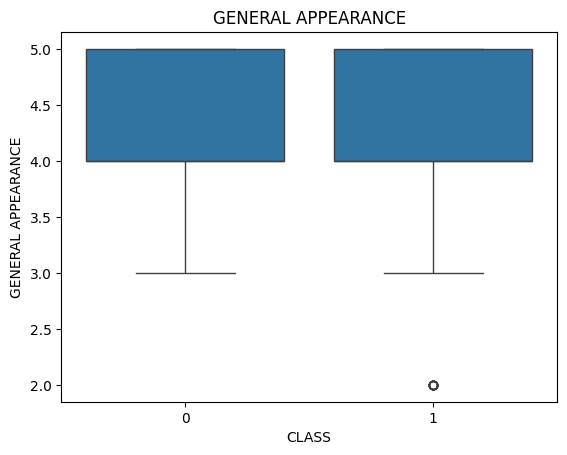

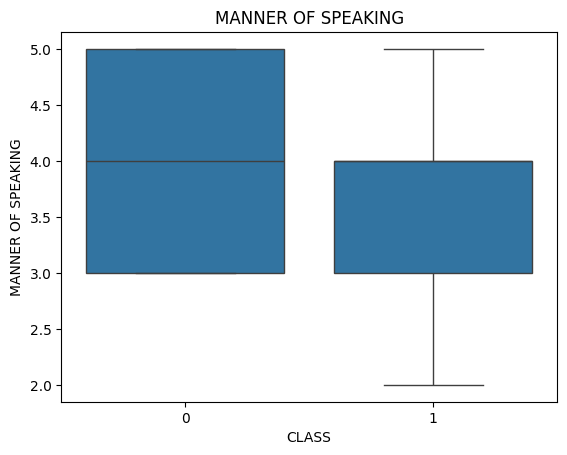

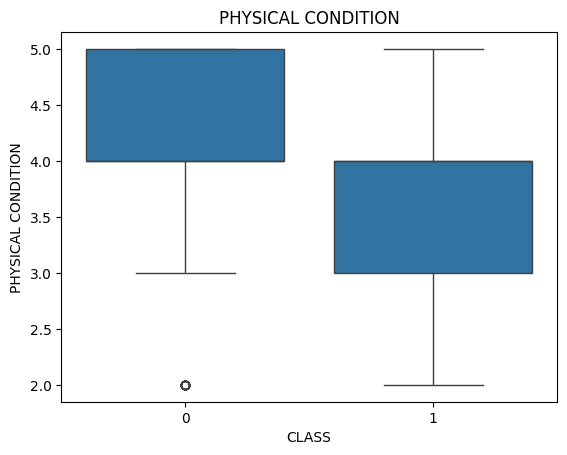

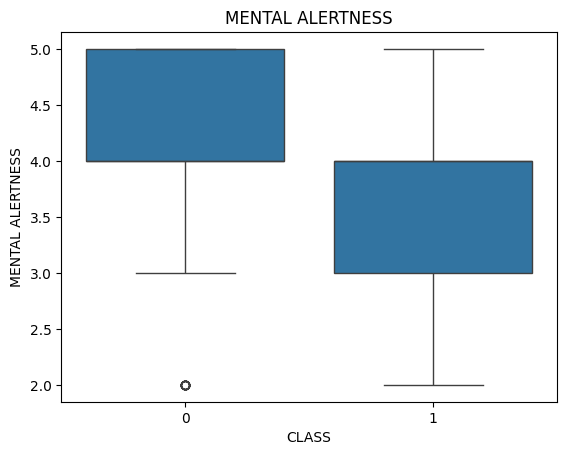

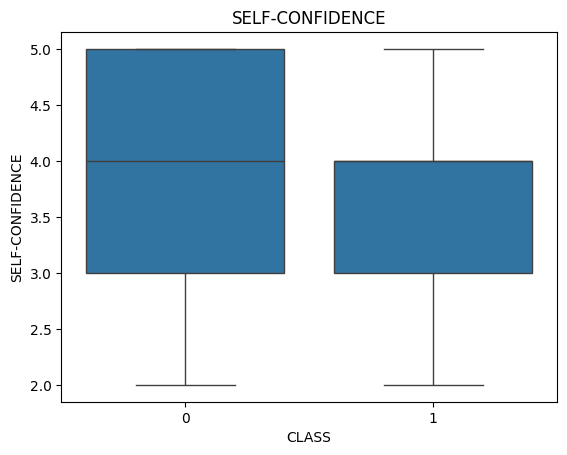

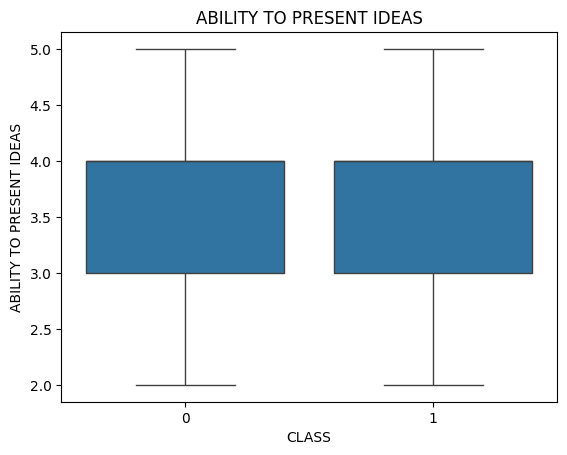

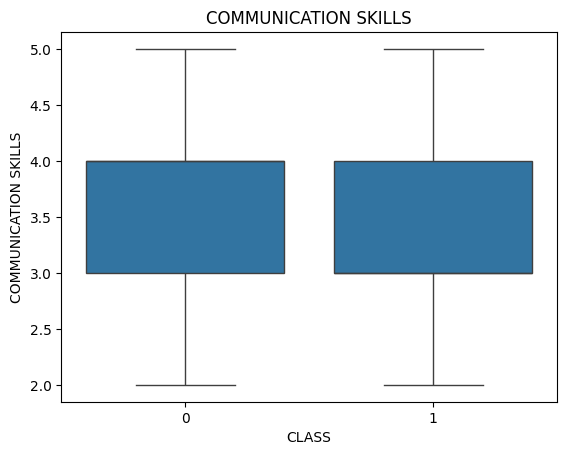

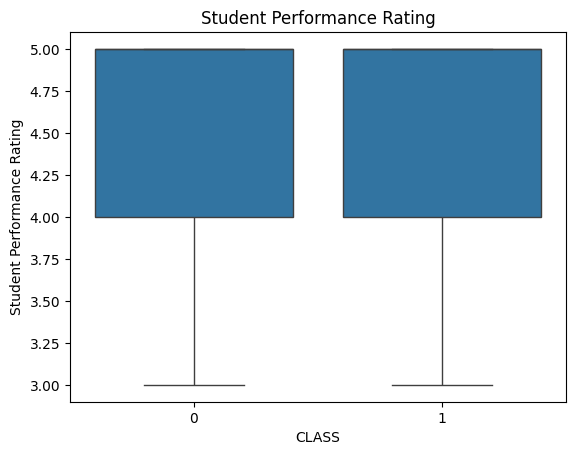

In [81]:
# check what features separate the two classes
import seaborn as sns
import matplotlib.pyplot as plt

features = df.columns.drop(["CLASS"])

for col in features:
    sns.boxplot(x=df["CLASS"], y=df[col])
    plt.title(col)
    plt.show()


In [146]:
# for col in features:
#     sns.kdeplot(data=df, x=col, hue="CLASS", fill=True)
#     plt.title(col)
#     plt.show()

In [134]:
df["CLASS"].value_counts(normalize=True)

CLASS
0    0.579812
1    0.420188
Name: proportion, dtype: float64

In [147]:
# split features and target
X = df.drop(["CLASS", "ABILITY TO PRESENT IDEAS"], axis=1)
y = df["CLASS"]

X

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,COMMUNICATION SKILLS,Student Performance Rating
0,4,5,4,5,5,5,5
1,4,4,4,4,4,3,5
2,4,3,3,3,3,2,5
3,3,3,3,2,3,3,5
4,4,4,3,3,4,3,5
...,...,...,...,...,...,...,...
2977,4,3,3,3,3,2,5
2978,3,4,4,4,4,4,5
2979,4,5,4,5,4,4,5
2980,4,4,4,3,4,3,5


In [148]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TO TEST: get difference if you scale using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [149]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [152]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values("Coefficient", ascending=False))

                      Feature  Coefficient
5        COMMUNICATION SKILLS     0.069992
4             SELF-CONFIDENCE     0.045750
6  Student Performance Rating     0.019851
0          GENERAL APPEARANCE     0.009572
2          PHYSICAL CONDITION    -0.070709
3            MENTAL ALERTNESS    -0.265425
1          MANNER OF SPEAKING    -0.296701


In [153]:
# check accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print(model.score(X_test, y_test))
print(model.score(X_train, y_train))



Accuracy: 0.61
0.6063651591289783
0.579874213836478


In [142]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.80      0.70       346
           1       0.55      0.33      0.41       251

    accuracy                           0.60       597
   macro avg       0.58      0.57      0.56       597
weighted avg       0.59      0.60      0.58       597

[[276  70]
 [167  84]]
